Cargando el archivo histórico...

Iniciando entrenamiento (Vigilando el 0.69)...
Epoch 1 | Train Loss: 0.6933 | Val Loss: 0.6928
Epoch 2 | Train Loss: 0.6926 | Val Loss: 0.6928
Epoch 3 | Train Loss: 0.6923 | Val Loss: 0.6926
Epoch 4 | Train Loss: 0.6921 | Val Loss: 0.6927
Epoch 5 | Train Loss: 0.6921 | Val Loss: 0.6928
Epoch 6 | Train Loss: 0.6919 | Val Loss: 0.6927
Epoch 7 | Train Loss: 0.6919 | Val Loss: 0.6928
Epoch 8 | Train Loss: 0.6917 | Val Loss: 0.6928
Epoch 9 | Train Loss: 0.6915 | Val Loss: 0.6928
Epoch 10 | Train Loss: 0.6916 | Val Loss: 0.6929
Epoch 11 | Train Loss: 0.6914 | Val Loss: 0.6930
Epoch 12 | Train Loss: 0.6915 | Val Loss: 0.6931
Epoch 13 | Train Loss: 0.6914 | Val Loss: 0.6931
Epoch 14 | Train Loss: 0.6912 | Val Loss: 0.6931
Epoch 15 | Train Loss: 0.6909 | Val Loss: 0.6932
Epoch 16 | Train Loss: 0.6910 | Val Loss: 0.6932
Epoch 17 | Train Loss: 0.6909 | Val Loss: 0.6934
Epoch 18 | Train Loss: 0.6908 | Val Loss: 0.6934
🛑 Early Stopping.

--- BACKTEST (ÚLTIMO ~AÑO) 

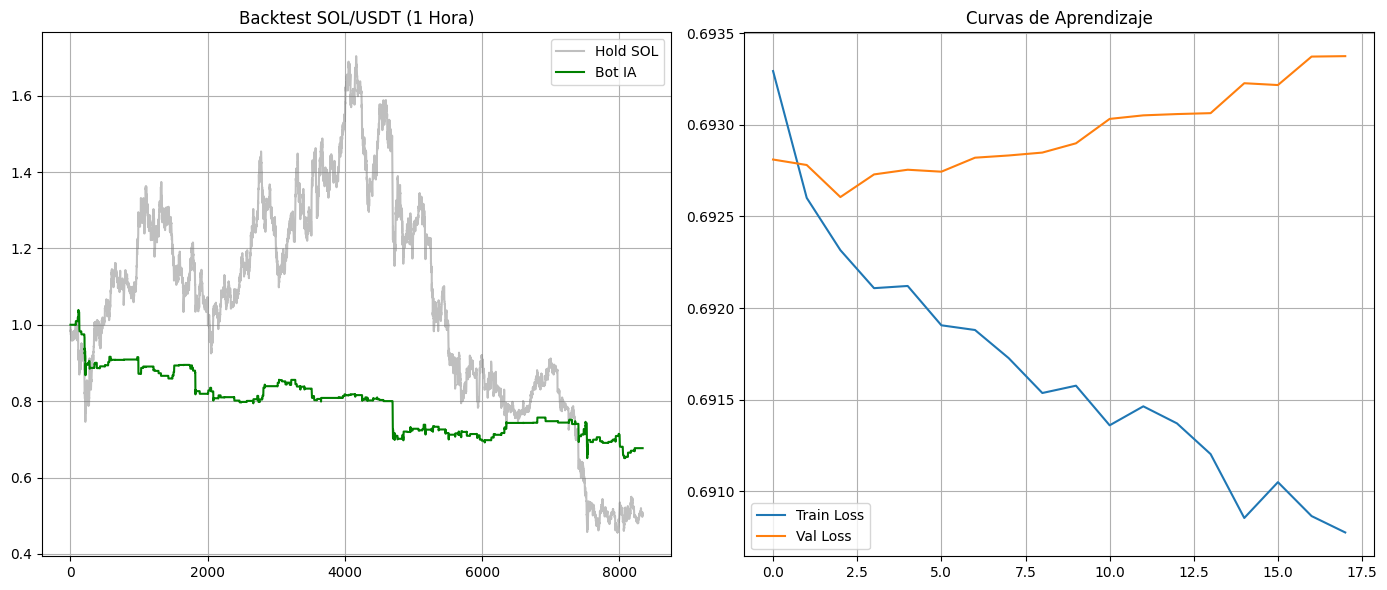

Retorno Bot: -32.30%
Retorno Mercado (Test Period): -49.79%


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib

# --- 1. CONFIGURACIÓN ---
FILE_NAME = 'datos_crypto_sol_btc_1h_historico.csv'
MODEL_NAME = 'modelo_crypto_sol_1h.pth'
SCALER_NAME = 'scaler_crypto_1h.pkl'

WINDOW_SIZE = 24      
INPUT_DIM = 8         
HIDDEN_DIM = 64       # Mantenemos la capacidad alta para que entienda patrones
NUM_LAYERS = 1        # BAJAMOS a 1 capa. (2 capas era demasiada profundidad y memorizaba)
DROPOUT_RATE = 0.3    # SUBIMOS al 30%. (0.1 era poco, 0.5 era demasiado)

BATCH_SIZE = 64
LEARNING_RATE = 0.0001  # <--- BAJAMOS EL LR (Añade un cero más: de 0.001 a 0.0001)
EPOCHS = 100            # <--- SUBIMOS LAS ÉPOCAS (Como aprende más lento, necesita más tiempo)  

# --- 2. CARGA DE DATOS ---
print("Cargando el archivo histórico...")
df = pd.read_csv(FILE_NAME, index_col=0, parse_dates=True)

# Las 8 pistas (features)
features =['lret_btc', 'lret_sol', 'vol_change_btc', 'vol_change_sol', 'ratio', 'z_score', 'rsi', 'dist_sma']
target = 'Target'

X = df[features].values
y = df[target].values

# Split
split_idx = int(len(X) * 0.8)
X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Secuencias
def create_sequences(data, target, window_size):
    xs, ys = [],[]
    for i in range(len(data) - window_size):
        xs.append(data[i : i+window_size])
        ys.append(target[i+window_size])
    return np.array(xs), np.array(ys)

X_train, y_train_seq = create_sequences(X_train_scaled, y_train, WINDOW_SIZE)
X_test, y_test_seq = create_sequences(X_test_scaled, y_test, WINDOW_SIZE)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train_seq).float()), shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test_seq).float()), shuffle=False, batch_size=BATCH_SIZE)

# --- 3. MODELO ---
class CryptoBotLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1):
        super(CryptoBotLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0)
        self.dropout = nn.Dropout(DROPOUT_RATE)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        return self.sigmoid(self.fc(out))

model = CryptoBotLSTM(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS)
criterion = nn.BCELoss()
# L2 Regularization
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# --- 4. ENTRENAMIENTO ---
print("\nIniciando entrenamiento (Vigilando el 0.69)...")
best_val_loss = float('inf')
patience = 10
train_losses, val_losses = [],[]

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch.unsqueeze(1))
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in test_loader:
            val_loss += criterion(model(X_val), y_val.unsqueeze(1)).item()
            
    avg_train = running_loss / len(train_loader)
    avg_val = val_loss / len(test_loader)
    
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")
    
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), MODEL_NAME)
        patience = 0
    else:
        patience += 1
        if patience >= 15:  # <--- SUBIR PACIENCIA A 15
            print("🛑 Early Stopping.")
            break

joblib.dump(scaler, SCALER_NAME)

# --- 5. BACKTEST ---
print("\n--- BACKTEST (ÚLTIMO ~AÑO) ---")
model.load_state_dict(torch.load(MODEL_NAME))
model.eval()

predictions =[]
with torch.no_grad():
    for X_b, _ in test_loader:
        predictions.extend(model(X_b).squeeze().tolist())

preds = np.array(predictions)
# Importante: Coger los retornos que corresponden exactamente a las secuencias de test
market_returns = df['lret_sol'].values[split_idx + WINDOW_SIZE :] 

# Umbrales
UPPER, LOWER = 0.53, 0.47 # Más sensibles porque 1h es más predecible
signals = np.zeros(len(preds))
signals[preds > UPPER] = 1
signals[preds < LOWER] = -1

# Costes (Asumimos Binance VIP 0 maker/taker bajo: 0.05% total, Borrow fee: 10% anual)
COMMISSION = 0.0005 
BORROW_FEE = (0.10 / 365 / 24) 

equity = [1.0]
position = 0

for i in range(len(preds)):
    current_ret = 0
    cost = 0
    if signals[i] != position: cost = COMMISSION
    
    if position == 1: current_ret = market_returns[i]
    elif position == -1: current_ret = -market_returns[i] - BORROW_FEE
        
    equity.append(equity[-1] * (1 + current_ret - cost))
    position = signals[i]

# Visión
plt.figure(figsize=(14, 6))
# Subplot 1: Curva de Capital
plt.subplot(1, 2, 1)
plt.plot(np.cumprod(1 + market_returns), label='Hold SOL', color='gray', alpha=0.5)
plt.plot(equity, label='Bot IA', color='green')
plt.title('Backtest SOL/USDT (1 Hora)')
plt.legend()
plt.grid(True)

# Subplot 2: Pérdidas (Romper la maldición)
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Retorno Bot: {(equity[-1]-1)*100:.2f}%")
print(f"Retorno Mercado (Test Period): {(np.cumprod(1 + market_returns)[-1]-1)*100:.2f}%")